# Notebook 07b — Closed-loop validation, bench results (Stage 3)

**Purpose.** Score the Stage-2 bench data against the pre-registration committed in
[notebooks/07a_closed_loop_sim.ipynb](07a_closed_loop_sim.ipynb) / [data/processed/phase3_preregistration.json](../data/processed/phase3_preregistration.json).

This notebook does **only** what the pre-registration committed to:
1. Loads the on-session refit (`models/calibration_<DATE>.json`) and the frozen gains.
2. Loads every closed-loop trial CSV in `data/raw/closed_loop_<DATE>/closed_loop_trials/`.
3. Computes the pre-registered metrics per trial.
4. Pairs trials by `(profile, pair_id)` from `trial_index.json`.
5. Runs the pre-registered primary and strong success criteria.
6. Reports the drift check.

No metric is added that was not in the pre-registration; no cherry-picking.

In [1]:
# Imports and session selection
import json
import sys
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.').resolve()
if (ROOT / 'motor_id').is_dir(): pass
elif (ROOT.parent / 'motor_id').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from motor_id.metrics import (rmse, rmse_window, rmse_deadzone, rmse_transient,
                               settling_time, overshoot, ss_error,
                               control_effort_rms,
                               paired_bootstrap_ci, wilcoxon_signed_rank_p,
                               standardised_pooled_diff_p)

# Pick the most-recent closed_loop_<DATE> session under data/raw/
candidates = sorted((ROOT / 'data' / 'raw').glob('closed_loop_*'))
candidates = [p for p in candidates if (p / 'trial_index.json').exists()]
assert candidates, 'No closed_loop_<DATE>/trial_index.json found.'
SESSION_DIR = candidates[-1]
SESSION_DATE = SESSION_DIR.name.replace('closed_loop_', '')
print(f'Session: {SESSION_DIR}  (date {SESSION_DATE})')

trial_index = json.loads((SESSION_DIR / 'trial_index.json').read_text())
print(f'Trials: {len(trial_index["trials"])}, seed={trial_index["seed"]}, n_pairs={trial_index["n_pairs"]}')

calib_json = json.loads((ROOT / 'models' / f'calibration_{SESSION_DATE}.json').read_text())
gains_json = json.loads((ROOT / 'models' / f'closed_loop_gains_{SESSION_DATE}.json').read_text())
print('On-session refit summary:')
ma = calib_json['model_A']
print(f"  Model A: K_A={ma['K_A_rpm_per_pwm']:.4f} rpm/PWM, tau={ma['tau_ms']:.1f} ms, Td={ma['Td_ms']:.1f} ms")
print(f"  Model C accel conditions: {[(c['direction'], c['pwm']) for c in calib_json['model_C']['accel_conditions']]}")
print(f"  Model C decel conditions: {[(c['direction'], c['target_pwm']) for c in calib_json['model_C']['decel_conditions']]}")

Session: /Users/piyush/code/System_Identification_DC_Motor/data/raw/closed_loop_2026-05-27  (date 2026-05-27)
Trials: 64, seed=20260527, n_pairs=8
On-session refit summary:
  Model A: K_A=0.7369 rpm/PWM, tau=155.0 ms, Td=6.6 ms
  Model C accel conditions: [('fwd', 160), ('fwd', 200), ('fwd', 240), ('rev', 160), ('rev', 200), ('rev', 240)]
  Model C decel conditions: [('fwd', 0), ('fwd', 160), ('rev', 0), ('rev', 160)]


In [2]:
# Load every closed-loop trial CSV
CL_DIR = SESSION_DIR / 'closed_loop_trials'

trials = []
for entry in trial_index['trials']:
    csv = CL_DIR / entry['csv']
    if not csv.exists():
        print(f'MISSING: {csv.name}')
        continue
    df = pd.read_csv(csv)
    trials.append({'meta': entry, 'df': df})
print(f'Loaded {len(trials)} closed-loop trials')

# Compute per-trial metrics
metric_rows = []
for tr in trials:
    m = tr['meta']; df = tr['df']
    t = df['t_ms'].to_numpy(dtype=float)
    ref = df['ref_rpm'].to_numpy(dtype=float)
    meas = df['meas_rpm'].to_numpy(dtype=float)
    pwm = df['pwm_cmd'].to_numpy(dtype=float)
    row = {
        'profile': m['profile'],
        'pair_id': m['pair_id'],
        'controller': m['controller'],
        'n_samples': len(df),
        'rmse_full': rmse(ref, meas),
        'rmse_deadzone': rmse_deadzone(t, ref, meas, deadzone_threshold=80.0),
        'rmse_transient': rmse_transient(t, ref, meas, tau_ms=200.0, horizons=5),
        'ss_error_last500ms': ss_error(t, ref, meas, window_ms=500.0),
        'rms_pwm': control_effort_rms(pwm),
        'max_abs_pwm': float(np.max(np.abs(pwm))),
        'saturated_frac': float(np.mean(np.abs(pwm) >= 254.5)),
    }
    metric_rows.append(row)
metrics_df = pd.DataFrame(metric_rows).sort_values(['profile', 'pair_id', 'controller']).reset_index(drop=True)
metrics_df.to_csv(ROOT / 'data' / 'processed' / 'closed_loop_metrics_per_trial.csv', index=False)
print(metrics_df.head(8).round(3).to_string(index=False))

Loaded 64 closed-loop trials


profile  pair_id controller  n_samples  rmse_full  rmse_deadzone  rmse_transient  ss_error_last500ms  rms_pwm  max_abs_pwm  saturated_frac
     P1        0       BASE       3900     14.122         17.469          25.083                 0.0  174.158        255.0           0.001
     P1        0       CASC       3901     11.288         12.985          19.765                 0.0  171.905        251.0           0.000
     P1        1       BASE       3901     14.033         17.333          24.863                 0.0  172.849        255.0           0.001
     P1        1       CASC       3901     11.246         12.857          19.631                 0.0  171.742        254.0           0.000
     P1        2       BASE       3901     14.013         17.291          24.837                 0.0  173.069        255.0           0.001
     P1        2       CASC       3900     11.198         12.882          19.549                 0.0  171.671        249.0           0.000
     P1        3       BASE

## Build the paired-difference table

Each `(profile, pair_id)` pair has one BASE and one CASC trial. The paired difference
is `BASE - CASC` for every metric — positive means cascade wins.

In [3]:
def pair_table(metrics_df, metric_name):
    rows = []
    for (profile, pair_id), grp in metrics_df.groupby(['profile', 'pair_id']):
        if set(grp.controller) != {'BASE', 'CASC'}:
            continue
        base_val = float(grp[grp.controller == 'BASE'][metric_name].iloc[0])
        casc_val = float(grp[grp.controller == 'CASC'][metric_name].iloc[0])
        rows.append({
            'profile': profile, 'pair_id': pair_id,
            'BASE': base_val, 'CASC': casc_val, 'diff_B_minus_C': base_val - casc_val,
        })
    return pd.DataFrame(rows)

PRIMARY_METRIC = 'rmse_full'
paired = pair_table(metrics_df, PRIMARY_METRIC)
print(f'Paired table on {PRIMARY_METRIC}:')
print(paired.round(3).to_string(index=False))

# Per-profile summary
def summarise(paired):
    out = []
    for p, grp in paired.groupby('profile'):
        diffs = grp.diff_B_minus_C.to_numpy()
        out.append({
            'profile': p,
            'n_pairs': int(len(diffs)),
            'mean_diff': float(np.mean(diffs)),
            'median_diff': float(np.median(diffs)),
            'sd_diff': float(np.std(diffs, ddof=1)) if len(diffs) > 1 else float('nan'),
        })
    return pd.DataFrame(out)

per_profile = summarise(paired)
print('\nPer-profile difference summary (positive = cascade wins):')
print(per_profile.round(3).to_string(index=False))

Paired table on rmse_full:
profile  pair_id   BASE   CASC  diff_B_minus_C
     P1        0 14.122 11.288           2.834
     P1        1 14.033 11.246           2.787
     P1        2 14.013 11.198           2.815
     P1        3 13.878 11.040           2.838
     P1        4 13.917 11.123           2.793
     P1        5 13.836 11.259           2.576
     P1        6 14.202 11.130           3.072
     P1        7 14.112 11.163           2.948
     P2        0  5.164  6.232          -1.068
     P2        1  5.242  6.430          -1.188
     P2        2  5.157  6.268          -1.111
     P2        3  5.233  6.506          -1.273
     P2        4  5.228  6.146          -0.918
     P2        5  5.385  6.158          -0.773
     P2        6  5.204  6.348          -1.144
     P2        7  5.227  6.509          -1.282
     P3        0 18.160 13.008           5.152
     P3        1 18.337 13.412           4.926
     P3        2 18.447 13.067           5.380
     P3        3 18.344 12.651   

## Pre-registered statistical tests

Reproducing the success criteria from [phase3_preregistration.json](../data/processed/phase3_preregistration.json) verbatim:

- **Primary**: `median(BASE − CASC) > 0` on each of P1, P2, P3 **AND** pooled within-profile-MAD-standardised paired-difference one-sided Wilcoxon `p < 0.10` on the {P1, P2, P3} pool.
- **Strong**: Primary holds **AND** 95% paired-bootstrap CI of `(BASE − CASC)` excludes zero on at least 2 of P1, P2, P3.
- **P4**: negative control.

In [4]:
TARGETED = ['P1', 'P2', 'P3']
NEG_CONTROL = 'P4'

# Per-profile bootstrap CI
ci_rows = []
for profile in TARGETED + [NEG_CONTROL]:
    sub = paired[paired.profile == profile]
    diffs = sub.diff_B_minus_C.to_numpy()
    mean, lo, hi = paired_bootstrap_ci(diffs, n_resamples=2000, alpha=0.05,
                                        random_state=20260527)
    p_wx = wilcoxon_signed_rank_p(diffs, alternative='greater')
    ci_rows.append({
        'profile': profile, 'n': int(len(diffs)),
        'median': float(np.median(diffs)) if len(diffs) else float('nan'),
        'mean': mean, 'ci_lo': lo, 'ci_hi': hi,
        'ci_excludes_zero': bool(lo > 0),
        'wilcoxon_p_greater': p_wx,
    })
ci_df = pd.DataFrame(ci_rows)
print(ci_df.round(4).to_string(index=False))

# Primary criterion
median_positive = bool((per_profile[per_profile.profile.isin(TARGETED)].median_diff > 0).all())

# Pooled MAD-standardised paired-difference test on P1+P2+P3
per_profile_diffs = {p: paired[paired.profile == p].diff_B_minus_C.to_numpy()
                     for p in TARGETED}
pooled = standardised_pooled_diff_p(per_profile_diffs, random_state=20260527)
print(f'\nPooled (MAD-standardised) paired-difference Wilcoxon (one-sided, greater):')
print(f'  pooled_mean = {pooled["pooled_mean"]:.4f}, n = {pooled["n"]}, p = {pooled["p_greater"]:.4f}')

primary_pass = median_positive and (pooled['p_greater'] < 0.10)
print(f'\n--- Primary criterion ---')
print(f'  Condition 1 (medians > 0 on P1,P2,P3): {median_positive}')
print(f'  Condition 2 (pooled p < 0.10):          {pooled["p_greater"] < 0.10}  (p={pooled["p_greater"]:.4f})')
print(f'  Primary: {"PASS" if primary_pass else "FAIL"}')

# Strong criterion: CI excludes zero on >=2 of P1, P2, P3
ci_targeted = ci_df[ci_df.profile.isin(TARGETED)]
n_excludes = int(ci_targeted.ci_excludes_zero.sum())
strong_pass = primary_pass and (n_excludes >= 2)
print(f'\n--- Strong criterion ---')
print(f'  CI excludes zero count: {n_excludes} / 3 (need >= 2)')
print(f'  Strong: {"PASS" if strong_pass else "FAIL"}')

# P4 negative-control commentary
p4_ci = ci_df[ci_df.profile == NEG_CONTROL].iloc[0]
print(f'\n--- P4 negative control ---')
print(f'  median = {p4_ci["median"]:.3f} rpm, CI = [{p4_ci["ci_lo"]:.3f}, {p4_ci["ci_hi"]:.3f}]')
print(f'  CI excludes zero: {p4_ci["ci_excludes_zero"]} (expected NOT to)')

profile  n  median    mean   ci_lo   ci_hi  ci_excludes_zero  wilcoxon_p_greater
     P1  8  2.8243  2.8329  2.7444  2.9293              True              0.0039
     P2  8 -1.1272 -1.0944 -1.2007 -0.9731             False              1.0000
     P3  8  5.1549  5.2170  5.0364  5.3978              True              0.0039
     P4  8  1.0049  1.0319  0.8584  1.2206              True              0.0039

Pooled (MAD-standardised) paired-difference Wilcoxon (one-sided, greater):
  pooled_mean = 21.3316, n = 24, p = 0.0003

--- Primary criterion ---
  Condition 1 (medians > 0 on P1,P2,P3): False
  Condition 2 (pooled p < 0.10):          True  (p=0.0003)
  Primary: FAIL

--- Strong criterion ---
  CI excludes zero count: 2 / 3 (need >= 2)
  Strong: FAIL

--- P4 negative control ---
  median = 1.005 rpm, CI = [0.858, 1.221]
  CI excludes zero: True (expected NOT to)


## Secondary metrics: deadzone, transient, control effort

In [5]:
# Pivot the headline metrics by (profile, controller)
def pivot_metric(name):
    pv = metrics_df.pivot_table(index='profile', columns='controller', values=name,
                                 aggfunc=['mean', 'std'])
    return pv

for m in ('rmse_full', 'rmse_deadzone', 'rmse_transient', 'rms_pwm'):
    print(f'\n=== {m} ===')
    pv = pivot_metric(m)
    print(pv.round(3).to_string())

# Effort ratio
effort_pv = metrics_df.pivot_table(index='profile', columns='controller',
                                    values='rms_pwm', aggfunc='mean')
effort_pv['ratio_CASC_over_BASE'] = effort_pv['CASC'] / effort_pv['BASE']
print('\nControl-effort ratio (CASC RMS PWM / BASE RMS PWM, mean over pairs):')
print(effort_pv.round(3).to_string())
fairness_ok = bool((effort_pv['ratio_CASC_over_BASE'] <= 1.5).all())
print(f'Fairness gate (ratio <= 1.5): {"PASS" if fairness_ok else "FAIL"}')


=== rmse_full ===
              mean            std       
controller    BASE    CASC   BASE   CASC
profile                                 
P1          14.014  11.181  0.129  0.083
P2           5.230   6.325  0.070  0.146
P3          18.344  13.127  0.102  0.270
P4          19.313  18.281  0.091  0.271

=== rmse_deadzone ===
              mean            std       
controller    BASE    CASC   BASE   CASC
profile                                 
P1          17.317  12.833  0.162  0.128
P2           6.869   8.662  0.112  0.232
P3          21.533  15.006  0.253  0.454

=== rmse_transient ===
              mean            std       
controller    BASE    CASC   BASE   CASC
profile                                 
P1          24.856  19.538  0.238  0.144
P2           5.623   6.875  0.080  0.166
P3          17.450  12.301  0.221  0.354
P4           4.801   4.735  0.234  0.277

=== rms_pwm ===
               mean             std       
controller     BASE     CASC   BASE   CASC
profile    

## Drift check (end-of-session vs start-of-session)

The DRIFT block repeats fwd/rev PWM=200 accel ×3 each. Compare against the
session-start calibration trials of the same condition.

In [6]:
# Drift check: compare drift_step_up_*_run* against step_up_*_run* (same PWM=200)
from motor_id.calibration import load_calib_trials

CALIB_DIR = SESSION_DIR / 'calib_trials'
DRIFT_DIR = SESSION_DIR / 'drift_trials'

if not DRIFT_DIR.exists() or not list(DRIFT_DIR.glob('*.csv')):
    print('No drift trials found.')
else:
    # Re-fit drift trials and compare against calibration accel fits at PWM=200
    drift_fits = load_calib_trials(DRIFT_DIR)
    calib_fits = load_calib_trials(CALIB_DIR)

    rows = []
    for direction in ('fwd', 'rev'):
        # session-start fits at PWM=200
        cs = calib_fits['accel']
        cs = cs[(cs.direction == direction) & (cs.pwm == 200) & cs.fit_ok]
        # drift fits at PWM=200 (loaded as 'drift' in load_calib_trials)
        ds = drift_fits['drift']
        ds = ds[(ds.direction == direction) & (ds.pwm == 200) & ds.fit_ok]
        if len(cs) == 0 or len(ds) == 0:
            print(f'  {direction} 200: insufficient data (start={len(cs)}, end={len(ds)})')
            continue
        rows.append({
            'direction': direction,
            'pwm': 200,
            'start_K_ss': float(cs.K_ss.mean()),
            'end_K_ss':   float(ds.K_ss.mean()),
            'dK_pct':     100 * (float(ds.K_ss.mean()) - float(cs.K_ss.mean())) / float(cs.K_ss.mean()),
            'start_tau':  float(cs.tau_ms.mean()),
            'end_tau':    float(ds.tau_ms.mean()),
            'dtau_pct':   100 * (float(ds.tau_ms.mean()) - float(cs.tau_ms.mean())) / float(cs.tau_ms.mean()),
            'n_start':    int(len(cs)), 'n_end': int(len(ds)),
        })
    drift_df = pd.DataFrame(rows)
    print(drift_df.round(2).to_string(index=False))
    drift_df.to_csv(ROOT / 'data' / 'processed' / 'closed_loop_drift_check.csv', index=False)

direction  pwm  start_K_ss  end_K_ss  dK_pct  start_tau  end_tau  dtau_pct  n_start  n_end
      fwd  200      126.14    134.59    6.70     102.00    96.71     -5.19        3      3
      rev  200     -133.14   -138.03    3.67      91.28    89.01     -2.49        3      3


## Figures

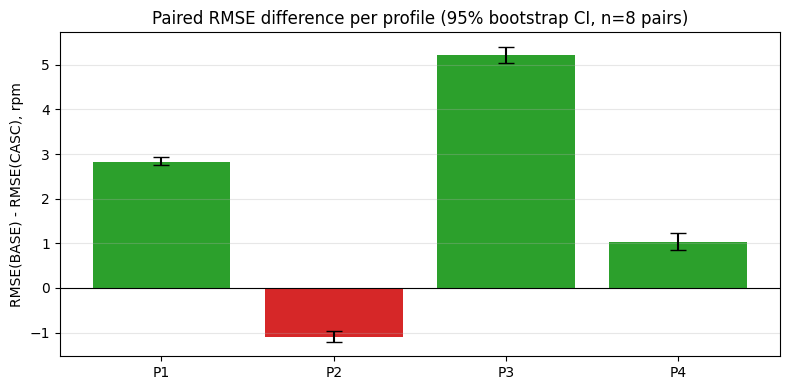

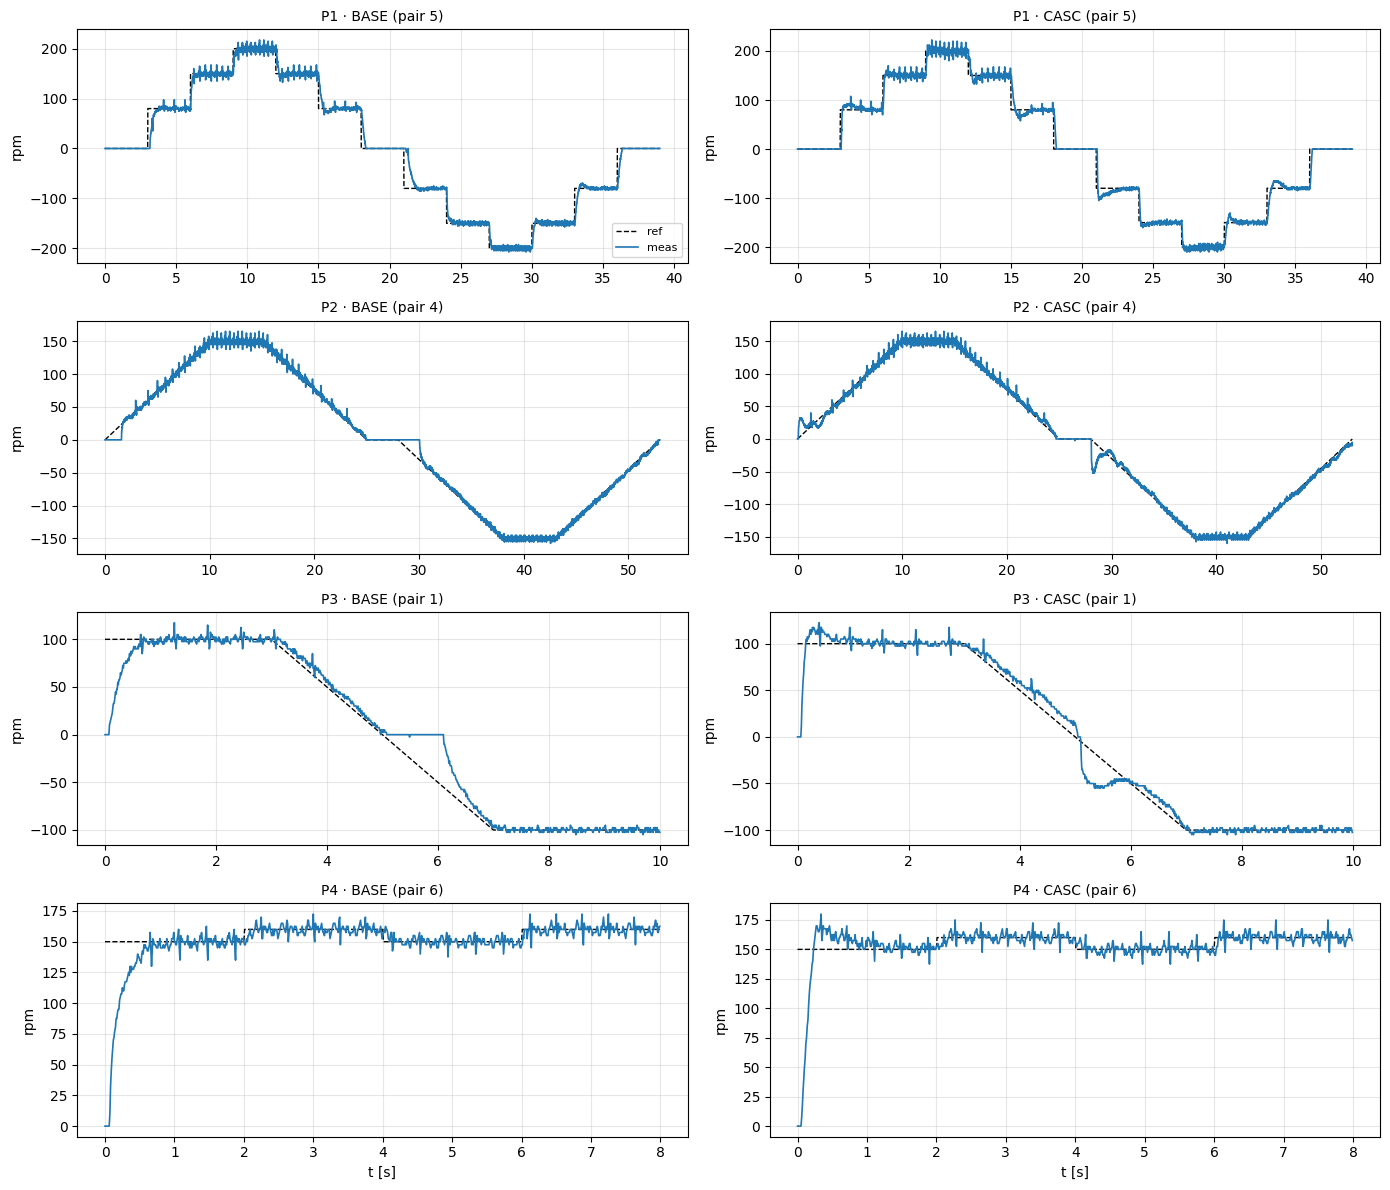

In [7]:
# Figure: paired RMSE diff per profile with CIs
fig, ax = plt.subplots(figsize=(8, 4))
profiles_order = ['P1', 'P2', 'P3', 'P4']
xs = np.arange(len(profiles_order))
means = [ci_df[ci_df.profile == p].iloc[0]['mean'] for p in profiles_order]
los   = [ci_df[ci_df.profile == p].iloc[0]['ci_lo'] for p in profiles_order]
his   = [ci_df[ci_df.profile == p].iloc[0]['ci_hi'] for p in profiles_order]
err_lo = [m - lo for m, lo in zip(means, los)]
err_hi = [hi - m for hi, m in zip(his, means)]
ax.bar(xs, means, yerr=[err_lo, err_hi], capsize=6,
       color=['tab:green' if (m > 0 and lo > 0) else
              ('tab:olive' if m > 0 else 'tab:red')
              for m, lo in zip(means, los)])
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(profiles_order)
ax.set_ylabel('RMSE(BASE) - RMSE(CASC), rpm')
ax.set_title('Paired RMSE difference per profile (95% bootstrap CI, n=8 pairs)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / '23_closed_loop_paired_diff.png', dpi=120)
plt.show()

# Figure: representative ref-vs-meas overlays per profile
fig, axs = plt.subplots(4, 2, figsize=(14, 12))
for i, profile in enumerate(profiles_order):
    for j, ctrl in enumerate(('BASE', 'CASC')):
        ax = axs[i, j]
        # pick the first pair of this profile/controller
        sel = [tr for tr in trials
               if tr['meta']['profile'] == profile and tr['meta']['controller'] == ctrl]
        if not sel:
            ax.set_title(f'{profile} {ctrl} (missing)'); continue
        tr = sel[0]
        df = tr['df']
        ax.plot(df.t_ms / 1000.0, df.ref_rpm, 'k--', lw=1.0, label='ref')
        ax.plot(df.t_ms / 1000.0, df.meas_rpm, lw=1.2, label='meas')
        ax.set_title(f'{profile} · {ctrl} (pair {tr["meta"]["pair_id"]})', fontsize=10)
        ax.set_ylabel('rpm'); ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='lower right', fontsize=8)
axs[-1, 0].set_xlabel('t [s]'); axs[-1, 1].set_xlabel('t [s]')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / '24_closed_loop_trajectories.png', dpi=120)
plt.show()

## Summary

In [8]:
# Save the headline summary
summary = {
    'session_date': SESSION_DATE,
    'pre_registration_sha256': '(see data/processed/phase3_preregistration.json)',
    'session_model_A': calib_json['model_A'],
    'gains_lambda_ms': gains_json['lambda_ms'],
    'n_trials_loaded': len(trials),
    'per_profile_diff_summary': per_profile.round(4).to_dict(orient='records'),
    'per_profile_CI': ci_df.round(4).to_dict(orient='records'),
    'pooled_pvalue': pooled,
    'primary_pass': bool(primary_pass),
    'strong_pass':  bool(strong_pass),
    'p4_ci_excludes_zero': bool(p4_ci['ci_excludes_zero']),
    'control_effort_ratios': effort_pv.round(4).to_dict(orient='index'),
    'fairness_gate_pass': bool(fairness_ok),
}
out = ROOT / 'data' / 'processed' / 'closed_loop_summary.json'
out.write_text(json.dumps(summary, indent=2, default=float))
print('Wrote', out)
print()
print('================ HEADLINE ================')
print(f'Primary criterion: {"PASS" if primary_pass else "FAIL"}')
print(f'Strong  criterion: {"PASS" if strong_pass else "FAIL"}')
print(f'P4 negative control behaves as expected: {not p4_ci["ci_excludes_zero"]}')
print(f'Fairness gate (effort ratio <= 1.5): {"PASS" if fairness_ok else "FAIL"}')
print('==========================================')

Wrote /Users/piyush/code/System_Identification_DC_Motor/data/processed/closed_loop_summary.json

================ HEADLINE ================
Primary criterion: FAIL
Strong  criterion: FAIL
P4 negative control behaves as expected: False
Fairness gate (effort ratio <= 1.5): PASS
